In [25]:
import os
import random
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

# parent_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
# sys.path.append(parent_dir)

# Import custom modules
from dino_wm.dino_models import VideoTransformer, normalize_acs
from dino_wm.test_loader import SplitTrajectoryDataset
from torch.utils.data import DataLoader
from torchvision import transforms

# Add directories to system path
# base_dir = os.path.abspath(os.path.join(os.path.dirname(__file__), ".."))
# sys.path.extend(
#     [
#         base_dir,
#         os.path.join(base_dir, "model_based_irl_torch"),
#         os.path.join(base_dir, "real_envs"),
#     ]
# )

# Load model
print(sys.path)
dino = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14_reg")

['/home/sunny/miniconda3/envs/anysafe/lib/python312.zip', '/home/sunny/miniconda3/envs/anysafe/lib/python3.12', '/home/sunny/miniconda3/envs/anysafe/lib/python3.12/lib-dynload', '', '/home/sunny/miniconda3/envs/anysafe/lib/python3.12/site-packages', '/home/sunny/AnySafe_Reachability', '..', '/tmp/tmp0f9kut5b']


Using cache found in /home/sunny/.cache/torch/hub/facebookresearch_dinov2_main


In [26]:
def transition_from_data(data, transition, device, use_amp=True):
    data1 = data["cam_zed_embd"].to(device)
    data2 = data["cam_rs_embd"].to(device)

    inputs1 = data1[:, :-1]
    inputs2 = data2[:, :-1]

    states = data["state"].to(device)[:, :-1]
    acs = normalize_acs(data["action"].to(device)[:, :-1], device=device)

    with torch.autocast(device_type="cuda", dtype=torch.float32, enabled=use_amp):
        with torch.no_grad():
            pred1, pred2, pred_state, pred_fail, semantic_feat = transition(
                inputs1, inputs2, states, acs
            )

    return pred1, pred2, pred_state, pred_fail, semantic_feat


def data_from_traj(traj):
    data = {}
    segment_length = traj["actions"].shape[0]
    # data["robot0_eye_in_hand_image"] = torch.tensor(
    #     np.array(traj["camera_0"][:]) * 255.0, dtype=torch.uint8
    # )
    data["agentview_image"] = torch.tensor(
        np.array(traj["camera_1"][:]) * 255.0, dtype=torch.uint8
    )
    # data["cam_rs_embd"] = torch.tensor(
    #     np.array(traj["cam_rs_embd"][:]), dtype=torch.float32
    # )
    data["cam_zed_embd"] = torch.tensor(
        np.array(traj["cam_zed_embd"][:]), dtype=torch.float32
    )
    data["state"] = torch.tensor(np.array(traj["states"][:]), dtype=torch.float32)
    data["action"] = torch.tensor(np.array(traj["actions"][:]), dtype=torch.float32)
    if "labels" in traj.keys():
        data["failure"] = torch.tensor(np.array(traj["labels"][:]), dtype=torch.float32)
    data["is_first"] = torch.zeros(segment_length)
    data["is_last"] = torch.zeros(segment_length)
    data["is_first"][0] = 1.0
    data["is_terminal"] = data["is_last"]
    data["discount"] = torch.ones(segment_length, dtype=torch.float32)
    return data


# Define transforms
transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

transform1 = transforms.Compose(
    [
        transforms.Resize(520),
        transforms.CenterCrop(518),
        transforms.ToTensor(),
        transforms.Normalize(mean=0.5, std=0.2),
    ]
)

DINO_transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
    ]
)

norm_transform = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)

In [27]:
use_amp = True
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = "cuda:0"

BL = 4
BS = 1024
open_loop = True
transition = VideoTransformer(
    image_size=(224, 224),
    dim=384,
    ac_dim=10,
    state_dim=3,
    depth=6,
    heads=16,
    mlp_dim=2048,
    num_frames=BL - 1,
    dropout=0.1,
).to(device)
# load_state_dict_flexible(transition, "../checkpoints_pa/encoder_0.1.pth")
# load_state_dict_flexible(transition, "../checkpoints/best_testing.pth")

transition.load_state_dict(
    torch.load("../checkpoints/best_classifier.pth"), strict=False
)
transition.eval()

hdf5_file = "/home/sunny/data/sweeper/train/consolidated.h5"
train_data = SplitTrajectoryDataset(
    hdf5_file,
    BL,
    split="train",
    num_test=0,
    provide_labels=False,
    only_pass_labeled_examples=False,
)
train_loader = DataLoader(train_data, batch_size=BS, shuffle=True, num_workers=4)

coverage_total = torch.zeros(
    (224, 224), dtype=torch.float32, device="cuda"
)  # if GPU

tot = len(train_data) // BS
for i, data in enumerate(train_loader):
    # [B, T, H, W, C] -> take last frame
    images = data["agentview_image"] # [data['failure'][:, -1] == 1.0]
    images = images[:, -1].to("cuda")  # keep on GPU

    R = images[..., 0]
    G = images[..., 1]
    B = images[..., 2]

    # Vectorized mask for the entire batch
    red_mask = (R > 50) & (R > G * 2.2) & (R > B * 1.5)

    # Convert bool to float and sum over batch
    coverage_total += red_mask.float().sum(dim=0)
    print(f"Processed {i + 1}/{tot} batches", end="\r")

/tmp/ipykernel_28221/2973901209.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
Using cache found in /home/sunny/.cache/torch/hub/facebookresearch_dinov2_main


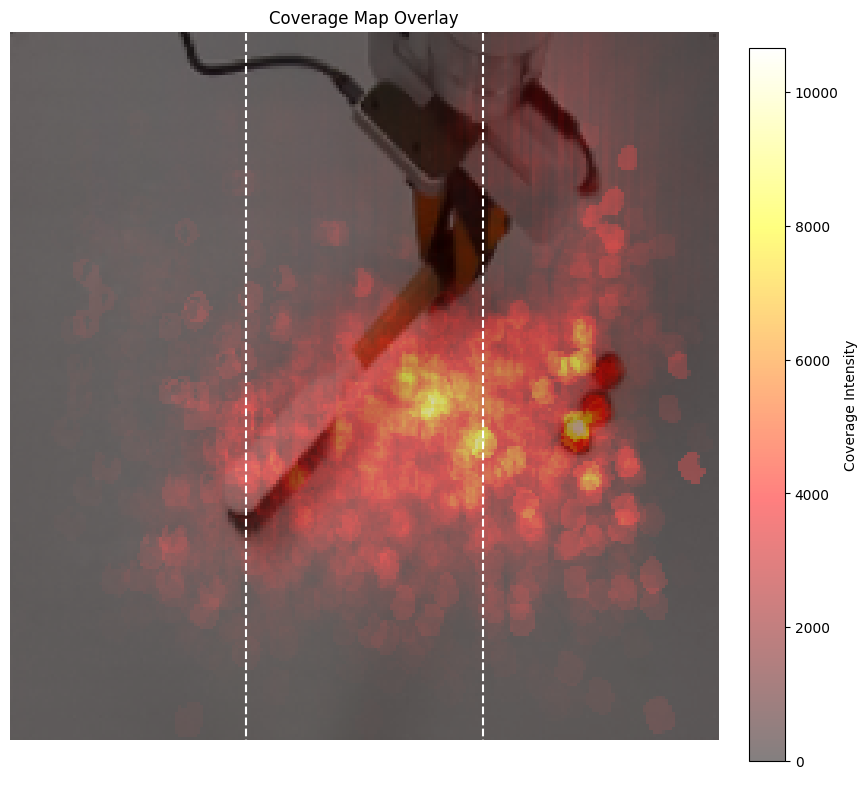

In [28]:
last_image = images[-1]  # Get the last image for visualization

# Normalize
# coverage_total /= coverage_total.max()

# Move to CPU for plotting
coverage_total = coverage_total.cpu()

# plot the coverage map over the last image
fig, ax = plt.subplots(figsize=(10, 10))
img1 = ax.imshow(last_image.cpu().numpy())
img2 = ax.imshow(coverage_total.cpu().numpy(), alpha=0.5, cmap="hot")

ax.set_title("Coverage Map Overlay")
ax.axis("off")

# Attach colorbar to the same axes so it matches the height
cbar = fig.colorbar(img2, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Coverage Intensity")
# add vlines at each third of the image width
ax.vlines(x=coverage_total.shape[1] // 3, ymin=0, ymax=coverage_total.shape[0], color="white", linestyle="--")
ax.vlines(x=2 * coverage_total.shape[1] // 3, ymin=0, ymax=coverage_total.shape[0], color="white", linestyle="--")

# save the figure
plt.savefig("coverage_map.png", dpi=300, bbox_inches="tight")